In [243]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet("../data/processed/whatsapp-20250329-141239-processed.parquet")

df

,timestamp,author,message,message_length,age,gender,is_inlaw,emoji_count,date,is_carnaval
0,2023-09-01 10:53:30,sprightly-rhinoceros,Wat we triestig weer zeg man man man\n,38,33.0,m,0.0,0,2023-09-01,False
1,2023-09-01 10:56:11,snappy-ermine,Pff echt he\n,13,30.0,m,0.0,0,2023-09-01,False
2,2023-09-01 10:56:39,decorated-shark,Duurt nog ff....pfffff 😢\n,26,55.0,f,0.0,1,2023-09-01,False
3,2023-09-01 10:57:03,snappy-ermine,Na vandaag wel goed weer op komst lijkt 👌🏼\n,44,30.0,m,0.0,2,2023-09-01,False
4,2023-09-01 10:58:44,decorated-shark,"Oh, gelukkig.\n",15,55.0,f,0.0,0,2023-09-01,False
...,...,...,...,...,...,...,...,...,...,...
8206,2025-03-16 16:12:35,good-natured-ermine,Als ze aan zet echt niet normaal\n,34,25.0,f,0.0,0,2025-03-16,False
8207,2025-03-16 17:16:14,crystalline-turkey,"Thanks 😊\nFf tussenstop op Tenerife, crew wis...",62,37.0,m,0.0,2,2025-03-16,False
8208,2025-03-16 22:33:05,crystalline-turkey,"Wij zijn weer in Nederland, net de wieltjes w...",62,37.0,m,0.0,0,2025-03-16,False
8209,2025-03-17 07:24:32,groovy-salmon,Welcome back! 💪🏻\n,18,35.0,m,0.0,2,2025-03-17,False


In [244]:
import re

# Clean de data nog wat meer

def remove_url(text):
    return re.sub(r"^https?:\/\/.*[\r\n]*", "", text)


df["message"] = df["message"].apply(lambda x: str(x).replace("\n", " "))
df["message"] = df["message"].apply(lambda x: remove_url(x))
df["message"] = df["message"].apply(lambda x: x.lower())

df

,timestamp,author,message,message_length,age,gender,is_inlaw,emoji_count,date,is_carnaval
0,2023-09-01 10:53:30,sprightly-rhinoceros,wat we triestig weer zeg man man man,38,33.0,m,0.0,0,2023-09-01,False
1,2023-09-01 10:56:11,snappy-ermine,pff echt he,13,30.0,m,0.0,0,2023-09-01,False
2,2023-09-01 10:56:39,decorated-shark,duurt nog ff....pfffff 😢,26,55.0,f,0.0,1,2023-09-01,False
3,2023-09-01 10:57:03,snappy-ermine,na vandaag wel goed weer op komst lijkt 👌🏼,44,30.0,m,0.0,2,2023-09-01,False
4,2023-09-01 10:58:44,decorated-shark,"oh, gelukkig.",15,55.0,f,0.0,0,2023-09-01,False
...,...,...,...,...,...,...,...,...,...,...
8206,2025-03-16 16:12:35,good-natured-ermine,als ze aan zet echt niet normaal,34,25.0,f,0.0,0,2025-03-16,False
8207,2025-03-16 17:16:14,crystalline-turkey,"thanks 😊 ff tussenstop op tenerife, crew wiss...",62,37.0,m,0.0,2,2025-03-16,False
8208,2025-03-16 22:33:05,crystalline-turkey,"wij zijn weer in nederland, net de wieltjes w...",62,37.0,m,0.0,0,2025-03-16,False
8209,2025-03-17 07:24:32,groovy-salmon,welcome back! 💪🏻,18,35.0,m,0.0,2,2025-03-17,False


In [245]:
# Pak alleen de authors met de hoogste f1 score

top_authors = [
    'decorated-shark',
    'sprightly-rhinoceros',
    'good-natured-ermine',
    'crystalline-turkey',
    'groovy-salmon'
]

df = df[df['author'].isin(top_authors)]

df

,timestamp,author,message,message_length,age,gender,is_inlaw,emoji_count,date,is_carnaval
0,2023-09-01 10:53:30,sprightly-rhinoceros,wat we triestig weer zeg man man man,38,33.0,m,0.0,0,2023-09-01,False
2,2023-09-01 10:56:39,decorated-shark,duurt nog ff....pfffff 😢,26,55.0,f,0.0,1,2023-09-01,False
4,2023-09-01 10:58:44,decorated-shark,"oh, gelukkig.",15,55.0,f,0.0,0,2023-09-01,False
6,2023-09-01 22:37:16,groovy-salmon,wij hebben nog een matras,27,35.0,m,0.0,0,2023-09-01,False
7,2023-09-01 22:37:29,groovy-salmon,mini matras van de vouwwagen,30,35.0,m,0.0,0,2023-09-01,False
...,...,...,...,...,...,...,...,...,...,...
8206,2025-03-16 16:12:35,good-natured-ermine,als ze aan zet echt niet normaal,34,25.0,f,0.0,0,2025-03-16,False
8207,2025-03-16 17:16:14,crystalline-turkey,"thanks 😊 ff tussenstop op tenerife, crew wiss...",62,37.0,m,0.0,2,2025-03-16,False
8208,2025-03-16 22:33:05,crystalline-turkey,"wij zijn weer in nederland, net de wieltjes w...",62,37.0,m,0.0,0,2025-03-16,False
8209,2025-03-17 07:24:32,groovy-salmon,welcome back! 💪🏻,18,35.0,m,0.0,2,2025-03-17,False


In [ ]:
# Tekststukken van ongeveer 200 woorden maken.

from sklearn.utils import shuffle

# Zet alle berichten per persoon aan elkaar vast
grouped = df.groupby('author')['message'].apply(lambda x: ' '.join(str(m) for m in x)).reset_index()

# Split in chunks van 200 woorden
def split_text(text, chunk_size=200):
    words = text.split()
    return [' '.join(words[i:i + chunk_size]) for i in range(0, len(words), chunk_size)]

chunk_data = []

for _, row in grouped.iterrows():
    chunks = split_text(row['message'], 200)
    for chunk in chunks:
        if len(chunk.split()) > 20:  # Alleen chunks met genoeg woorden
            chunk_data.append({'author': row['author'], 'text': chunk})

chunks_df = pd.DataFrame(chunk_data)
# chunks_df = shuffle(chunks_df).reset_index(drop=True)
chunks_df.head()

,author,text
0,crystalline-turkey,lekker hoor 😂😂😂 ☝️❤️ bizar 😂 in die flat wonen...
1,crystalline-turkey,heel nice 🤩🤩🤩 🥳🥳🥳🍺 kris? deed t al 6 jaar ofzo...
2,crystalline-turkey,11024 (bouwplaat) leuk 🤩 en lekker ook. of wan...
3,crystalline-turkey,valt hier nog mee met de wegligging van mijn f...
4,crystalline-turkey,⛵️ weer online heeeeuuuuuuul gaaf! ja wel bijz...


In [ ]:
# het model snapt geen tekst, dus omzetten in een cijfer-representatie

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(chunks_df['text'])

X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 15820 stored elements and shape (158, 1000)>

In [254]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Verdeel in train en test data: 20% testdata & 42 is het antwoord op alles :)
X_train, X_test, y_train, y_test = train_test_split(X, chunks_df['author'], test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
report = classification_report(y_test, y_pred)
print(report)


                      precision    recall  f1-score   support

  crystalline-turkey       1.00      0.17      0.29         6
     decorated-shark       1.00      0.80      0.89         5
 good-natured-ermine       0.55      1.00      0.71         6
       groovy-salmon       0.89      1.00      0.94         8
sprightly-rhinoceros       1.00      1.00      1.00         7

            accuracy                           0.81        32
           macro avg       0.89      0.79      0.76        32
        weighted avg       0.89      0.81      0.78        32





| **Metric**   | **Betekenis** |
|--------------|---------------|
| **Precision** | Hoe vaak het model juist is als het zegt "dit is van persoon X". |
| **Recall**    | Hoe goed het model álle stukjes van persoon X weet te herkennen. |
| **F1-score**  | Een soort gemiddelde van precision en recall. |
| **Support**   | Het aantal test-chunks per persoon (dus hoeveel stukjes tekst er per persoon zijn in de testset). |


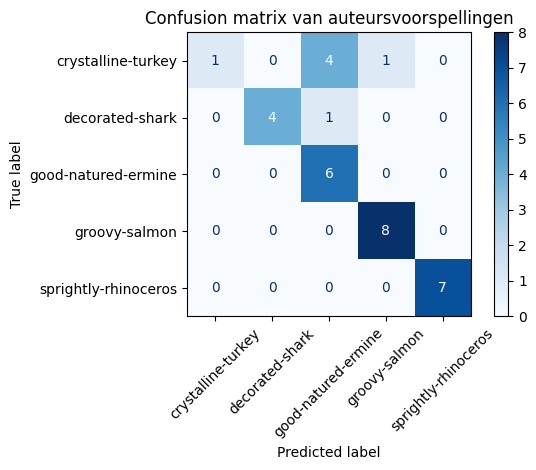

In [257]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# y_test: echte labels
# y_pred: voorspellingen van het model

# confusion matrix laat zien wanneer het model goed en fout voorspelt
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion matrix van auteursvoorspellingen")
plt.tight_layout()
plt.show()


#### Auteursherkenning in de familiechat (nieuwe run)

De confusion matrix hieronder toont de prestaties van het model bij het voorspellen van de auteur van een tekstchunk.

- Het model herkent **groovy-salmon** en **sprightly-rhinoceros** perfect alle berichten zijn goed geclassificeerd.
- Ook **good-natured-ermine** wordt grotendeels goed herkend
- **decorated-shark** is in 1 geval verward met een andere auteur.
- **crystalline-turkey** is het lastigst: 4 van de 6 berichten worden fout geclassificeerd, vooral als **good-natured-ermine**.

De donkere diagonale vlakken laten zien hoe goed het model is in het herkennen van schrijfstijlen. Hoe donkerder op de diagonaal, hoe beter.

De overall **accuracy is nog steeds hoog** . Dit suggereert dat de schrijfstijl van sommige groepsleden goed te onderscheiden is op basis van hun berichten.


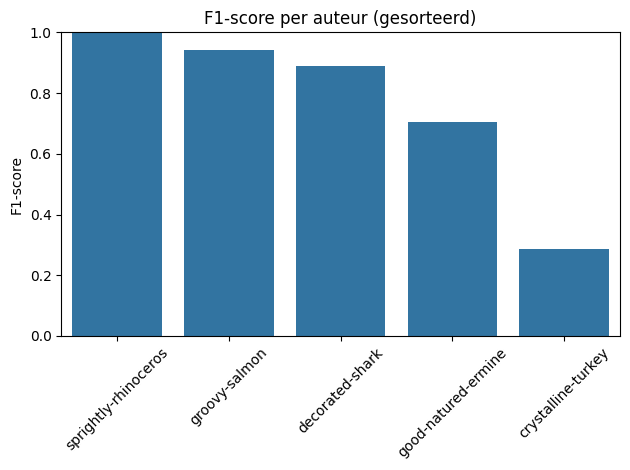

In [259]:
from sklearn.metrics import classification_report
import seaborn as sns

# Genereer classification report
report = classification_report(y_test, y_pred, output_dict=True)

# Haal f1-scores op en filter alleen bekende klassen
f1_scores = {label: metrics["f1-score"] for label, metrics in report.items() if label in model.classes_}

# Sorteer op f1-score van hoog naar laag
sorted_f1 = dict(sorted(f1_scores.items(), key=lambda item: item[1], reverse=True))

# Plot gesorteerde scores
sns.barplot(x=list(sorted_f1.keys()), y=list(sorted_f1.values()))
plt.ylim(0, 1)
plt.ylabel("F1-score")
plt.title("F1-score per auteur (gesorteerd)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()